In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Global paths (edit if needed)
DATA_PATH = "/Users/chiying/Documents/Predictive-Individual-Coursework/data/bank.csv"
OUT_DIR = "/Users/chiying/Documents/Predictive-Individual-Coursework/Graph"

# Create output directory for figures
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# Load dataset
df = pd.read_csv(DATA_PATH)

# Auto-detect target column: deposit first, then y
if "deposit" in df.columns:
    TARGET_COL = "deposit"
elif "y" in df.columns:
    TARGET_COL = "y"
else:
    print("Target column not found. Available columns:")
    print(df.columns.tolist())
    raise SystemExit("Stopping because neither 'deposit' nor 'y' exists.")

print(f"Detected target column: {TARGET_COL}")

def print_checklist(step1_validated: str, modeling_implication: str) -> None:
    print(f"Step 1 assumption validated: {step1_validated}")
    print(f"Modeling implication: {modeling_implication}")

def target_to_binary(series: pd.Series) -> pd.Series:
    # Assumes positive class is "yes" (case-insensitive)
    return series.astype(str).str.strip().str.lower().eq("yes").astype(int)

Detected target column: deposit



Module 1) Dataset overview & target imbalance
Shape: (11162, 17)

Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']

Dtypes:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

Target counts:
deposit
no     5873
yes    5289
Name: count, dtype: int64

Target proportions:
deposit
no     0.5262
yes    0.4738
Name: proportion, dtype: float64

Majority-class baseline accuracy: 0.5262


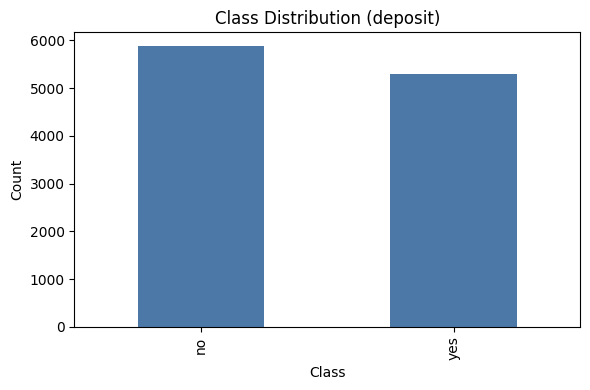

Step 1 assumption validated: Class balance must be quantified before choosing evaluation metrics.
Modeling implication: Use imbalance-aware metrics; do not rely on accuracy alone.


In [5]:
# Module 1) Dataset overview & target imbalance
print("\n" + "=" * 80)
print("Module 1) Dataset overview & target imbalance")
print("=" * 80)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nDtypes:")
print(df.dtypes)

target_counts = df[TARGET_COL].value_counts(dropna=False)
target_props = df[TARGET_COL].value_counts(normalize=True, dropna=False)

print("\nTarget counts:")
print(target_counts)
print("\nTarget proportions:")
print(target_props.round(4))

majority_baseline = target_props.max()
print(f"\nMajority-class baseline accuracy: {majority_baseline:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
target_counts.sort_values(ascending=False).plot(kind="bar", ax=ax, color="#4C78A8")
ax.set_title(f"Class Distribution ({TARGET_COL})")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
fig.tight_layout()
fig.savefig(Path(OUT_DIR) / "module1_class_distribution.png", dpi=150)
plt.show()

# Narrative note:
# Imbalance matters because accuracy may look high while minority-class detection remains weak.

print_checklist(
    "Class balance must be quantified before choosing evaluation metrics.",
    "Use imbalance-aware metrics; do not rely on accuracy alone.",
)


Module 2) Data quality & missingness

Missing values summary:
           missing_count  missing_percent
age                    0              0.0
day                    0              0.0
poutcome               0              0.0
previous               0              0.0
pdays                  0              0.0
campaign               0              0.0
duration               0              0.0
month                  0              0.0
contact                0              0.0
job                    0              0.0
loan                   0              0.0
housing                0              0.0
balance                0              0.0
default                0              0.0
education              0              0.0
marital                0              0.0
deposit                0              0.0

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']

'unknown' frequency per categorical column:
      col

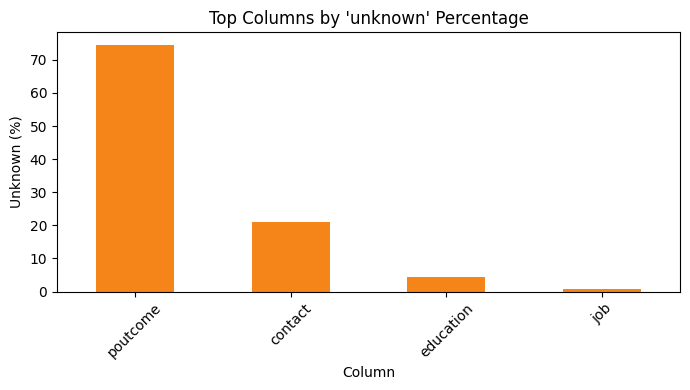

Step 1 assumption validated: Formal NA values are not the only missingness mechanism; placeholders must be checked.
Modeling implication: Placeholder-heavy columns can distort category effects and require careful interpretation.


In [6]:
# Module 2) Data quality & missingness (including 'unknown')
print("\n" + "=" * 80)
print("Module 2) Data quality & missingness")
print("=" * 80)

missing_count = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)
missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_pct
}).sort_values("missing_percent", ascending=False)

print("\nMissing values summary:")
print(missing_table)

cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print("\nCategorical columns:")
print(cat_cols)

unknown_records = []
for col in cat_cols:
    unknown_count = df[col].astype(str).str.strip().str.lower().eq("unknown").sum()
    unknown_pct = (unknown_count / len(df)) * 100
    unknown_records.append({
        "column": col,
        "unknown_count": int(unknown_count),
        "unknown_percent": round(unknown_pct, 2),
    })

unknown_table = pd.DataFrame(unknown_records).sort_values("unknown_percent", ascending=False)
print("\n'unknown' frequency per categorical column:")
print(unknown_table)

# Optional plot: top columns by unknown percentage (if any unknowns exist)
unknown_nonzero = unknown_table[unknown_table["unknown_count"] > 0]
if not unknown_nonzero.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    unknown_nonzero.head(10).plot(
        kind="bar",
        x="column",
        y="unknown_percent",
        ax=ax,
        color="#F58518",
        legend=False,
    )
    ax.set_title("Top Columns by 'unknown' Percentage")
    ax.set_xlabel("Column")
    ax.set_ylabel("Unknown (%)")
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    fig.savefig(Path(OUT_DIR) / "module2_unknown_frequency.png", dpi=150)
    plt.show()

# Narrative note:
# Placeholder categories like 'unknown' may represent incomplete information and should be treated explicitly in analysis.

print_checklist(
    "Formal NA values are not the only missingness mechanism; placeholders must be checked.",
    "Placeholder-heavy columns can distort category effects and require careful interpretation.",
)


Module 3) Leakage investigation (pre-contact setting)

Duration summary by target:
          count        mean         std  min    25%    50%    75%     max
deposit                                                                  
no       5873.0  223.130257  208.577530  2.0   94.0  163.0  282.0  3284.0
yes      5289.0  537.294574  392.525262  8.0  244.0  426.0  725.0  3881.0


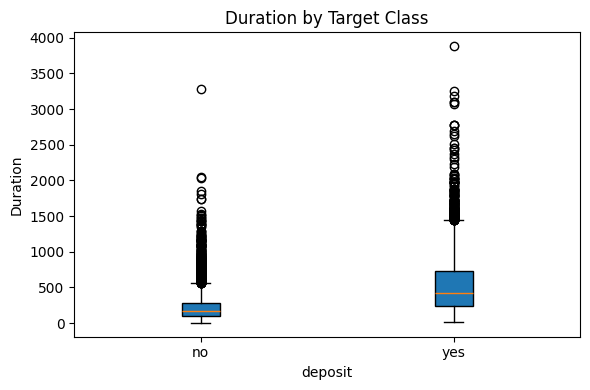


Binned conversion rate by duration:
      duration_bin  target_bin
0    (1.999, 77.0]    0.024691
1    (77.0, 119.0]    0.156028
2   (119.0, 158.0]    0.279155
3   (158.0, 204.0]    0.365572
4   (204.0, 255.0]    0.464093
5   (255.0, 323.0]    0.506775
6   (323.0, 420.0]    0.558744
7   (420.0, 585.0]    0.697051
8   (585.0, 838.0]    0.799820
9  (838.0, 3881.0]    0.894170


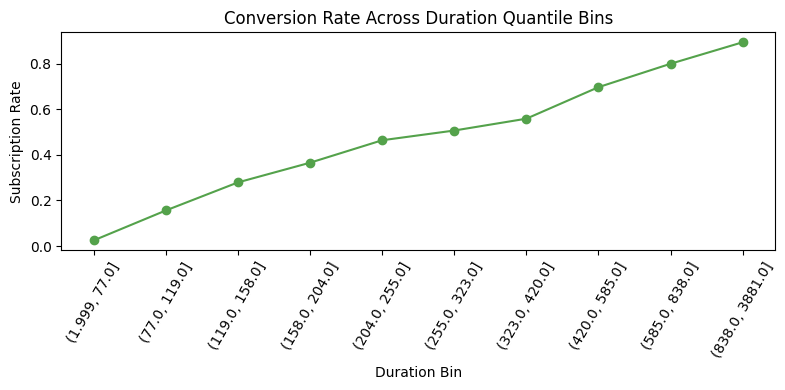


Narrative note:
- For pre-contact prediction, 'duration' is post-outcome information and is a leakage risk.

Campaign timing note:
- 'campaign' may be timing-ambiguous; verify whether it is known at prediction time without future information.
Step 1 assumption validated: Only variables known at/ before call initiation should be considered valid predictors.
Modeling implication: Exclude post-outcome fields (especially duration) from pre-contact modeling inputs.


In [7]:
# Module 3) Leakage investigation (pre-contact setting)
print("\n" + "=" * 80)
print("Module 3) Leakage investigation (pre-contact setting)")
print("=" * 80)

if "duration" in df.columns:
    target_bin = target_to_binary(df[TARGET_COL])

    # Summary
    print("\nDuration summary by target:")
    print(df.groupby(TARGET_COL)["duration"].describe())

    # Plot 1: Boxplot of duration by target class
    grouped = list(df.groupby(TARGET_COL))
    box_data = [g["duration"].dropna() for _, g in grouped]
    box_labels = [str(name) for name, _ in grouped]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.boxplot(box_data, tick_labels=box_labels, patch_artist=True)
    ax.set_title("Duration by Target Class")
    ax.set_xlabel(TARGET_COL)
    ax.set_ylabel("Duration")
    fig.tight_layout()
    fig.savefig(Path(OUT_DIR) / "module3_duration_boxplot_by_target.png", dpi=150)
    plt.show()

    # Plot 2: Binned conversion rate by duration quantile
    tmp = df[[TARGET_COL, "duration"]].dropna().copy()
    tmp["target_bin"] = target_to_binary(tmp[TARGET_COL])
    tmp["duration_bin"] = pd.qcut(tmp["duration"], q=10, duplicates="drop")
    conv_rate = tmp.groupby("duration_bin", observed=False)["target_bin"].mean().reset_index()
    conv_rate["duration_bin_str"] = conv_rate["duration_bin"].astype(str)

    print("\nBinned conversion rate by duration:")
    print(conv_rate[["duration_bin", "target_bin"]])

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(conv_rate["duration_bin_str"], conv_rate["target_bin"], marker="o", color="#54A24B")
    ax.set_title("Conversion Rate Across Duration Quantile Bins")
    ax.set_xlabel("Duration Bin")
    ax.set_ylabel("Subscription Rate")
    ax.tick_params(axis="x", rotation=60)
    fig.tight_layout()
    fig.savefig(Path(OUT_DIR) / "module3_duration_binned_conversion_rate.png", dpi=150)
    plt.show()

    # Narrative notes:
    print("\nNarrative note:")
    print("- For pre-contact prediction, 'duration' is post-outcome information and is a leakage risk.")
else:
    print("Column 'duration' not found; duration leakage analysis skipped.")

if "campaign" in df.columns:
    print("\nCampaign timing note:")
    print("- 'campaign' may be timing-ambiguous; verify whether it is known at prediction time without future information.")

print_checklist(
    "Only variables known at/ before call initiation should be considered valid predictors.",
    "Exclude post-outcome fields (especially duration) from pre-contact modeling inputs.",
)

Detected target column: deposit
Columns used: campaign, deposit, duration
Descriptive statistics of campaign by target:
          count      mean       std  min  25%  50%  75%   max
deposit                                                      
no       5873.0  2.839264  3.244474  1.0  1.0  2.0  3.0  63.0
yes      5289.0  2.141047  1.921826  1.0  1.0  2.0  3.0  32.0


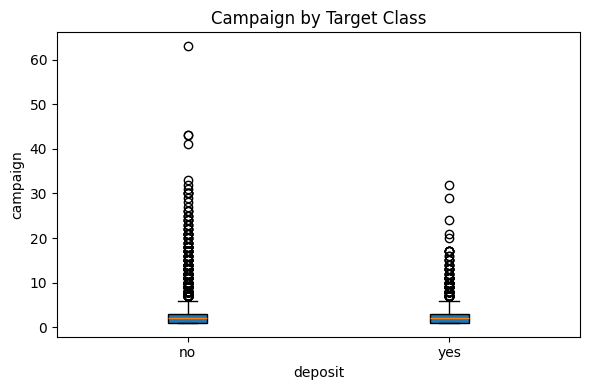

Subscription rate across campaign quantile bins:
   campaign_bin  subscription_rate     n
0  (0.999, 2.0]           0.506261  7826
1    (2.0, 3.0]           0.467827  1321
2    (3.0, 5.0]           0.396867  1149
3   (5.0, 63.0]           0.292148   866


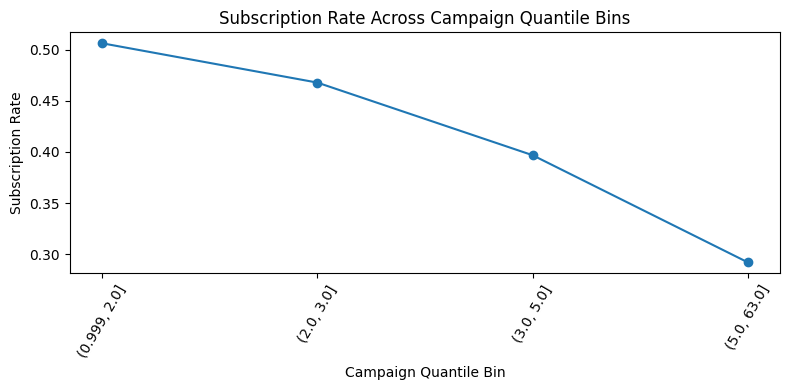

Pearson correlation (campaign, duration): -0.0416

Narrative interpretation:
- Is campaign likely known at prediction time?
  Campaign can be known only if defined strictly as contacts completed BEFORE the scoring moment.
- Does it appear to accumulate during the campaign?
  If campaign has a minimum near 1 and a long upper tail, that is consistent with accumulation across attempts.
- Could it encode post-contact information?
  Yes, potentially. If campaign includes the current/future contact count relative to the prediction moment,
  it leaks temporal information and may inflate apparent performance.
- Correlation context: campaign-duration correlation is negative (-0.0416).
  This does not prove leakage by itself, but association with call process variables warrants timing validation.

Recommendation:
Operationally verify the timestamp logic for campaign before modeling.
For a strict pre-contact setup, use only the count available up to (not including) the decision-time contact event

In [13]:
# ## Leakage-Focused Analysis for `campaign` (Pre-Contact Prediction Setting)

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Detect target
if "deposit" in df.columns:
    TARGET_COL = "deposit"
elif "y" in df.columns:
    TARGET_COL = "y"
else:
    print("Target column not found. Available columns:")
    print(df.columns.tolist())
    raise SystemExit("Stopping: neither 'deposit' nor 'y' exists.")

# Required columns check
required = ["campaign", TARGET_COL]
missing = [c for c in required if c not in df.columns]
if missing:
    print("Missing required columns:", missing)
    raise SystemExit("Stopping due to missing required columns.")

# Optional column for correlation step
has_duration = "duration" in df.columns

# Binary target helper (assumes positive class is 'yes')
df["_target_bin"] = df[TARGET_COL].astype(str).str.strip().str.lower().eq("yes").astype(int)

print(f"Detected target column: {TARGET_COL}")
print(f"Columns used: campaign, {TARGET_COL}" + (", duration" if has_duration else ""))


# %% [markdown]
# ### 1) Descriptive statistics of campaign by target

# %%
campaign_by_target = df.groupby(TARGET_COL)["campaign"].describe()
print("Descriptive statistics of campaign by target:")
print(campaign_by_target)


# %% [markdown]
# ### 2) Boxplot of campaign by target class

# %%
grouped = list(df.groupby(TARGET_COL))
box_data = [g["campaign"].dropna() for _, g in grouped]
box_labels = [str(name) for name, _ in grouped]

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(box_data, tick_labels=box_labels, patch_artist=True)
ax.set_title("Campaign by Target Class")
ax.set_xlabel(TARGET_COL)
ax.set_ylabel("campaign")
fig.tight_layout()
fig.savefig(Path(OUT_DIR) / "campaign_leakage_boxplot_by_target.png", dpi=150)
plt.show()


# %% [markdown]
# ### 3) Subscription rate across campaign quantile bins

# %%
tmp = df[["campaign", "_target_bin"]].dropna().copy()

# Use quantile bins; duplicates='drop' handles repeated values safely
tmp["campaign_bin"] = pd.qcut(tmp["campaign"], q=10, duplicates="drop")

bin_summary = (
    tmp.groupby("campaign_bin", observed=False)
    .agg(subscription_rate=("_target_bin", "mean"), n=("_target_bin", "size"))
    .reset_index()
)
bin_summary["campaign_bin_str"] = bin_summary["campaign_bin"].astype(str)

print("Subscription rate across campaign quantile bins:")
print(bin_summary[["campaign_bin", "subscription_rate", "n"]])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(bin_summary["campaign_bin_str"], bin_summary["subscription_rate"], marker="o")
ax.set_title("Subscription Rate Across Campaign Quantile Bins")
ax.set_xlabel("Campaign Quantile Bin")
ax.set_ylabel("Subscription Rate")
ax.tick_params(axis="x", rotation=60)
fig.tight_layout()
fig.savefig(Path(OUT_DIR) / "campaign_leakage_binned_subscription_rate.png", dpi=150)
plt.show()


# %% [markdown]
# ### 4) Correlation between campaign and duration

# %%
if has_duration:
    corr_value = df[["campaign", "duration"]].corr(method="pearson").loc["campaign", "duration"]
    print(f"Pearson correlation (campaign, duration): {corr_value:.4f}")
else:
    corr_value = None
    print("Column 'duration' not found; correlation step skipped.")


# %% [markdown]
# ### 5) Short narrative interpretation (data-supported template)

# %%
print("\nNarrative interpretation:")
print("- Is campaign likely known at prediction time?")
print("  Campaign can be known only if defined strictly as contacts completed BEFORE the scoring moment.")

print("- Does it appear to accumulate during the campaign?")
print("  If campaign has a minimum near 1 and a long upper tail, that is consistent with accumulation across attempts.")

print("- Could it encode post-contact information?")
print("  Yes, potentially. If campaign includes the current/future contact count relative to the prediction moment,")
print("  it leaks temporal information and may inflate apparent performance.")

if corr_value is not None:
    direction = "positive" if corr_value > 0 else "negative" if corr_value < 0 else "near-zero"
    print(f"- Correlation context: campaign-duration correlation is {direction} ({corr_value:.4f}).")
    print("  This does not prove leakage by itself, but association with call process variables warrants timing validation.")

print("\nRecommendation:")
print("Operationally verify the timestamp logic for campaign before modeling.")
print("For a strict pre-contact setup, use only the count available up to (not including) the decision-time contact event.")



Module 4) Numerical distributions & outlier diagnostics
Numeric columns analyzed: ['age', 'balance', 'pdays', 'campaign', 'previous', 'duration']


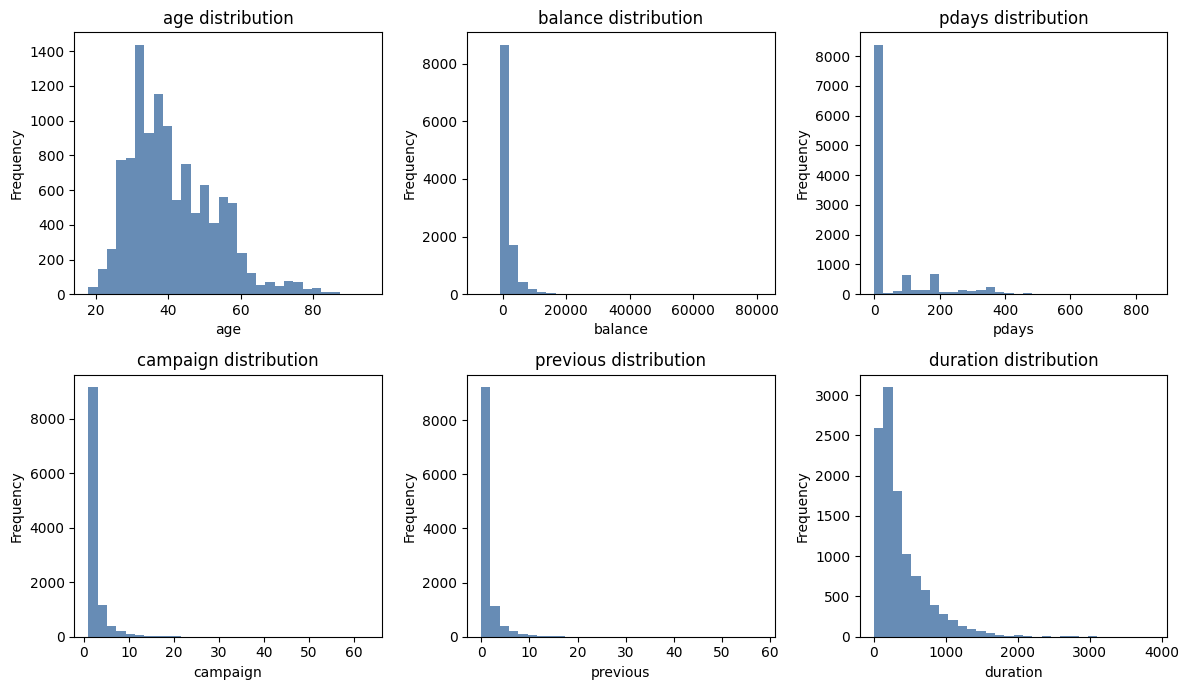

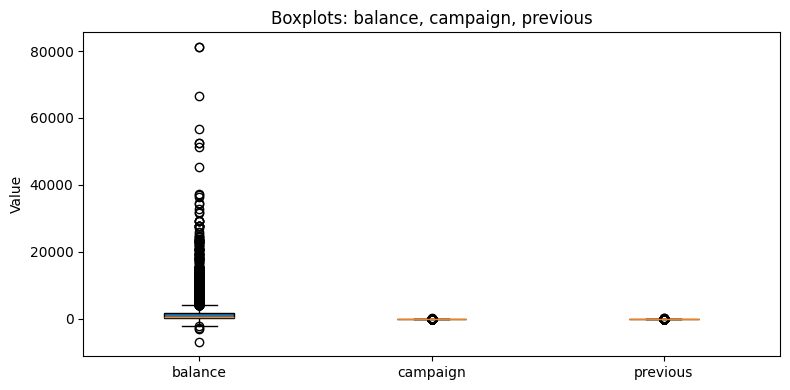


IQR outlier diagnostics:
age: Q1=32.000, Q3=49.000, IQR=17.000, lower=6.500, upper=74.500, extreme_prop=0.0153
balance: Q1=122.000, Q3=1708.000, IQR=1586.000, lower=-2257.000, upper=4087.000, extreme_prop=0.0945
pdays: Q1=-1.000, Q3=20.750, IQR=21.750, lower=-33.625, upper=53.375, extreme_prop=0.2464
campaign: Q1=1.000, Q3=3.000, IQR=2.000, lower=-2.000, upper=6.000, extreme_prop=0.0538
previous: Q1=0.000, Q3=1.000, IQR=1.000, lower=-1.500, upper=2.500, extreme_prop=0.1127
duration: Q1=138.000, Q3=496.000, IQR=358.000, lower=-399.000, upper=1033.000, extreme_prop=0.0570

Proportion with pdays == -1: 0.7457

pdays summary excluding -1:
count    2838.000000
mean      204.818182
std       122.196901
min         1.000000
25%        98.000000
50%       182.000000
75%       286.000000
max       854.000000
Name: pdays, dtype: float64
Step 1 assumption validated: Numeric predictors may contain skewed distributions and sentinel-coded values.
Modeling implication: Model choice and feature inter

In [8]:
#Module 4) Numerical distributions & outlier diagnostics
print("\n" + "=" * 80)
print("Module 4) Numerical distributions & outlier diagnostics")
print("=" * 80)

num_focus = ["age", "balance", "pdays", "campaign", "previous", "duration"]
num_cols = [c for c in num_focus if c in df.columns]
print("Numeric columns analyzed:", num_cols)

# Plot 1: Multi-panel histograms (single figure)
if num_cols:
    n = len(num_cols)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 3.5 * nrows))
    axes_flat = axes.ravel() if hasattr(axes, "ravel") else [axes]

    for i, col in enumerate(num_cols):
        ax = axes_flat[i]
        df[col].dropna().plot(kind="hist", bins=30, ax=ax, color="#4C78A8", alpha=0.85)
        ax.set_title(f"{col} distribution")
        ax.set_xlabel(col)
    for j in range(len(num_cols), len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.tight_layout()
    fig.savefig(Path(OUT_DIR) / "module4_numeric_histograms.png", dpi=150)
    plt.show()

# Plot 2: Boxplots for balance/campaign/previous if present
box_cols = [c for c in ["balance", "campaign", "previous"] if c in df.columns]
if box_cols:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.boxplot([df[c].dropna() for c in box_cols], tick_labels=box_cols, patch_artist=True)
    ax.set_title("Boxplots: balance, campaign, previous")
    ax.set_ylabel("Value")
    fig.tight_layout()
    fig.savefig(Path(OUT_DIR) / "module4_boxplots_balance_campaign_previous.png", dpi=150)
    plt.show()

# IQR thresholds and extreme proportions
print("\nIQR outlier diagnostics:")
for col in num_cols:
    s = df[col].dropna()
    if s.empty:
        continue
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    extreme_prop = ((s < lower) | (s > upper)).mean()
    print(
        f"{col}: Q1={q1:.3f}, Q3={q3:.3f}, IQR={iqr:.3f}, "
        f"lower={lower:.3f}, upper={upper:.3f}, extreme_prop={extreme_prop:.4f}"
    )

# pdays sentinel analysis
if "pdays" in df.columns:
    p_neg1_prop = df["pdays"].eq(-1).mean()
    print(f"\nProportion with pdays == -1: {p_neg1_prop:.4f}")
    pdays_nonneg1 = df.loc[df["pdays"] != -1, "pdays"]
    print("\npdays summary excluding -1:")
    print(pdays_nonneg1.describe())

# Narrative notes:
# - Skewness and extreme values can influence model behavior and metric stability.
# - pdays == -1 is typically a sentinel state (e.g., no prior recent contact), not a regular continuous value.
# - EDA only: no outlier removal or modification performed.

print_checklist(
    "Numeric predictors may contain skewed distributions and sentinel-coded values.",
    "Model choice and feature interpretation should account for heavy tails and extreme values.",
)



Module 5) Categorical structure
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']

Unique level counts per categorical column:
job          12
month        12
education     4
poutcome      4
marital       3
contact       3
default       2
housing       2
loan          2
deposit       2
dtype: int64

Top levels and rare levels (count <= 20):

Column: job
Top levels:
job
management     2566
blue-collar    1944
technician     1823
admin.         1334
services        923
Name: count, dtype: int64
Rare levels (sample up to 10):
None

Column: marital
Top levels:
marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64
Rare levels (sample up to 10):
None

Column: education
Top levels:
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64
Rare levels (sample up to 10):
None

Column: default
Top levels:
default
no     10994
yes      168
N

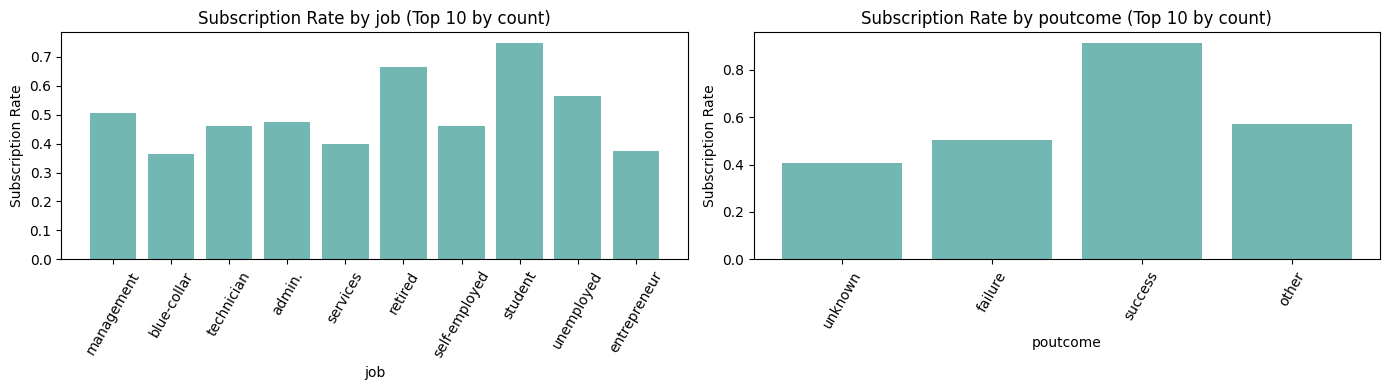

Step 1 assumption validated: Categorical variables may have sparse levels that affect stability.
Modeling implication: Rare-level effects should be interpreted cautiously when drawing modeling conclusions.


In [9]:
# Module 5) Categorical structure
print("\n" + "=" * 80)
print("Module 5) Categorical structure")
print("=" * 80)

cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print("Categorical columns:", cat_cols)

if cat_cols:
    unique_counts = df[cat_cols].nunique(dropna=False).sort_values(ascending=False)
    print("\nUnique level counts per categorical column:")
    print(unique_counts)

    print("\nTop levels and rare levels (count <= 20):")
    for col in cat_cols:
        vc = df[col].value_counts(dropna=False)
        print(f"\nColumn: {col}")
        print("Top levels:")
        print(vc.head(5))
        rare = vc[vc <= 20]
        print("Rare levels (sample up to 10):")
        print(rare.sort_values(ascending=True).head(10) if not rare.empty else "None")

# Choose 1–2 key categorical features if available
key_cat = [c for c in ["job", "poutcome"] if c in cat_cols][:2]
target_bin = target_to_binary(df[TARGET_COL])

rate_frames = []
for col in key_cat:
    grp = (
    pd.DataFrame({col: df[col], "target_bin": target_bin})
    .groupby(col, dropna=False)["target_bin"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "subscription_rate", "count": "n"})
    .sort_values("n", ascending=False)
)
    print(f"\nSubscription rate by {col}:")
    print(grp)
    rate_frames.append((col, grp.head(10)))

# 1 figure (can contain up to 2 panels)
if rate_frames:
    fig, axes = plt.subplots(1, len(rate_frames), figsize=(7 * len(rate_frames), 4))
    if len(rate_frames) == 1:
        axes = [axes]
    for ax, (col, top_df) in zip(axes, rate_frames):
        ax.bar(top_df.index.astype(str), top_df["subscription_rate"], color="#72B7B2")
        ax.set_title(f"Subscription Rate by {col} (Top 10 by count)")
        ax.set_xlabel(col)
        ax.set_ylabel("Subscription Rate")
        ax.tick_params(axis="x", rotation=60)
    fig.tight_layout()
    fig.savefig(Path(OUT_DIR) / "module5_conversion_rate_top_categories.png", dpi=150)
    plt.show()

# Narrative note:
# Rare categories may produce unstable empirical rates and noisy pattern interpretation.

print_checklist(
    "Categorical variables may have sparse levels that affect stability.",
    "Rare-level effects should be interpreted cautiously when drawing modeling conclusions.",
)


Module 6) Fairness-oriented base rate analysis

Subscription rate by age group:
age_group
(17.999, 32.0]    0.527517
(32.0, 39.0]      0.439252
(39.0, 49.0]      0.404490
(49.0, 95.0]      0.519700
Name: target_bin, dtype: float64

Subscription rate by marital group:
marital
single      0.543491
divorced    0.481052
married     0.433790
Name: target_bin, dtype: float64


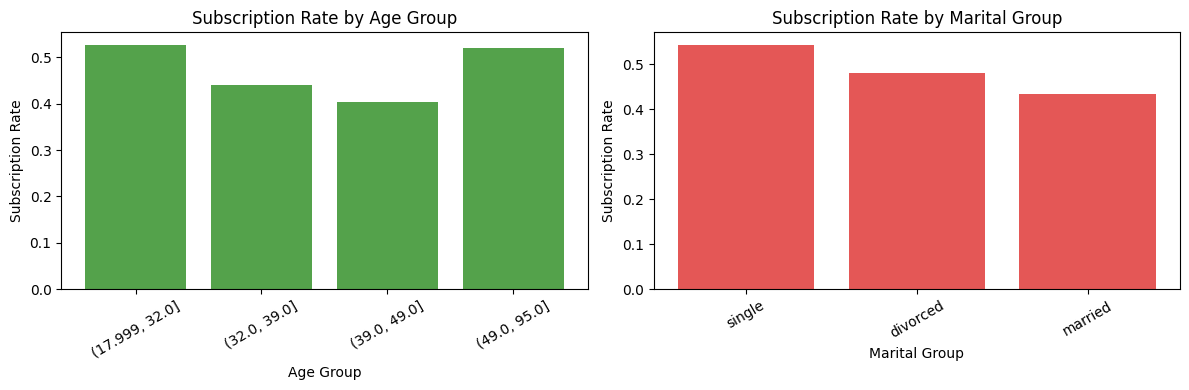

Step 1 assumption validated: Group-level base rates may differ across age and marital categories.
Modeling implication: Fairness metric choice (DP vs EO) should reflect observed base-rate heterogeneity.


In [10]:
# Module 6) Fairness-oriented base rate analysis
print("\n" + "=" * 80)
print("Module 6) Fairness-oriented base rate analysis")
print("=" * 80)

target_bin = target_to_binary(df[TARGET_COL])

# Age groups (data-driven quantile bins)
age_group_col = None
if "age" in df.columns:
    age_group_col = pd.qcut(df["age"], q=4, duplicates="drop")
    age_rate = (
        pd.DataFrame({"age_group": age_group_col.astype(str), "target_bin": target_bin})
        .groupby("age_group", dropna=False)["target_bin"]
        .mean()
        .sort_index()
    )
    print("\nSubscription rate by age group:")
    print(age_rate)
else:
    age_rate = pd.Series(dtype=float)

# Marital groups
if "marital" in df.columns:
    marital_rate = (
        pd.DataFrame({"marital": df["marital"], "target_bin": target_bin})
        .groupby("marital", dropna=False)["target_bin"]
        .mean()
        .sort_values(ascending=False)
    )
    print("\nSubscription rate by marital group:")
    print(marital_rate)
else:
    marital_rate = pd.Series(dtype=float)

# 1 figure with two panels (age + marital)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if not age_rate.empty:
    axes[0].bar(age_rate.index.astype(str), age_rate.values, color="#54A24B")
    axes[0].set_title("Subscription Rate by Age Group")
    axes[0].set_xlabel("Age Group")
    axes[0].set_ylabel("Subscription Rate")
    axes[0].tick_params(axis="x", rotation=30)
else:
    axes[0].set_visible(False)

if not marital_rate.empty:
    axes[1].bar(marital_rate.index.astype(str), marital_rate.values, color="#E45756")
    axes[1].set_title("Subscription Rate by Marital Group")
    axes[1].set_xlabel("Marital Group")
    axes[1].set_ylabel("Subscription Rate")
    axes[1].tick_params(axis="x", rotation=30)
else:
    axes[1].set_visible(False)

fig.tight_layout()
fig.savefig(Path(OUT_DIR) / "module6_group_subscription_rates.png", dpi=150)
plt.show()

# Narrative note:
# If base rates differ across groups, Demographic Parity (equal positive rates) and
# Equal Opportunity (equal true-positive rates) may not be simultaneously attainable.

print_checklist(
    "Group-level base rates may differ across age and marital categories.",
    "Fairness metric choice (DP vs EO) should reflect observed base-rate heterogeneity.",
)


In [11]:
# Module 7) Subgroup support check
print("\n" + "=" * 80)
print("Module 7) Subgroup support check")
print("=" * 80)

SMALL_N_THRESHOLD = 100

# Recreate age groups if available
if "age" in df.columns:
    age_groups = pd.qcut(df["age"], q=4, duplicates="drop").astype(str)
    age_counts = age_groups.value_counts(dropna=False).sort_index()
    print("\nCounts per age group:")
    print(age_counts)

    small_age = age_counts[age_counts < SMALL_N_THRESHOLD]
    if not small_age.empty:
        print(f"\nWarning: small age subgroups detected (< {SMALL_N_THRESHOLD}):")
        print(small_age)
else:
    age_groups = None
    print("\nAge column not found; age subgroup counts skipped.")

if "marital" in df.columns:
    marital_counts = df["marital"].value_counts(dropna=False)
    print("\nCounts per marital group:")
    print(marital_counts)

    small_marital = marital_counts[marital_counts < SMALL_N_THRESHOLD]
    if not small_marital.empty:
        print(f"\nWarning: small marital subgroups detected (< {SMALL_N_THRESHOLD}):")
        print(small_marital)
else:
    print("\nMarital column not found; marital subgroup counts skipped.")

# Optional intersection counts (age group x marital)
if (age_groups is not None) and ("marital" in df.columns):
    inter_counts = (
        pd.DataFrame({"age_group": age_groups, "marital": df["marital"]})
        .value_counts(dropna=False)
        .rename("count")
        .reset_index()
        .sort_values("count", ascending=False)
    )
    print("\nTop intersection subgroup counts (age_group x marital):")
    print(inter_counts.head(15))

# Narrative note:
# Small subgroup support can make fairness-rate estimates unstable and increase uncertainty.

print_checklist(
    "Fairness analysis requires adequate subgroup sample sizes for stable estimates.",
    "Small-N subgroup metrics should be interpreted cautiously and reported with support counts.",
)

print("\nEDA complete. Figures saved to:", OUT_DIR)


Module 7) Subgroup support check

Counts per age group:
age
(17.999, 32.0]    2980
(32.0, 39.0]      2889
(39.0, 49.0]      2628
(49.0, 95.0]      2665
Name: count, dtype: int64

Counts per marital group:
marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64

Top intersection subgroup counts (age_group x marital):
         age_group   marital  count
0     (49.0, 95.0]   married   2011
1   (17.999, 32.0]    single   2010
2     (39.0, 49.0]   married   1794
3     (32.0, 39.0]   married   1672
4     (32.0, 39.0]    single    938
5   (17.999, 32.0]   married    874
6     (49.0, 95.0]  divorced    505
7     (39.0, 49.0]    single    421
8     (39.0, 49.0]  divorced    413
9     (32.0, 39.0]  divorced    279
10    (49.0, 95.0]    single    149
11  (17.999, 32.0]  divorced     96
Step 1 assumption validated: Fairness analysis requires adequate subgroup sample sizes for stable estimates.
Modeling implication: Small-N subgroup metrics should be interpreted cautio